In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os

In [2]:
api_token = os.getenv("HUGGINGFACE_API_KEY")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=100,
    temperature=0.1,
    huggingfacehub_api_token=api_token,
)

/home/sangam/agentic_ai/agentic_ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
chat_model = ChatHuggingFace(llm=llm)

In [22]:
chat_model.invoke("what is the capital of France?")

AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 42, 'total_tokens': 50}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ec40e-58e0-7a33-be21-73da56c04d1f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 8, 'total_tokens': 50})

In [31]:
from langgraph.graph import StateGraph, START, END
from typing import Literal, TypedDict, Annotated
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [6]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]  

In [17]:
def chat_node(state: ChatState):
    message = state['messages']
    response = chat_model.invoke(message)
    return {'messages': [response]}

In [32]:
#create graph
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

#add node
graph.add_node('chatnode', chat_node)

#add edges
graph.add_edge(START, 'chatnode')
graph.add_edge('chatnode', END)

#compile graph
workflow = graph.compile(checkpointer=checkpointer)

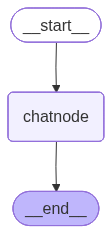

In [19]:
workflow

In [24]:
initial_state = {
    'messages': [
        HumanMessage(content="What is the capital of France?")
    ]
}

In [25]:
final_state = workflow.invoke(initial_state)

In [27]:
final_state

print(f"Answer: {final_state['messages'][-1].content}")

Answer: The capital of France is Paris.


In [36]:
thread_id = '2'

while True:
    user_input = input("You: ")
    print(f"User input: {user_input}")
    if user_input.lower() in ['exit', 'quit']:
        print("Exiting chat.")
        break
    config = {'configurable': {'thread_id': thread_id}}
    final_state = workflow.invoke({'messages': [HumanMessage(content=user_input)]}, config=config)
    print(f"Bot: {final_state['messages'][-1].content}")

User input: what is my name
Bot: I don't have any information about your name. I'm a large language model, I don't have the ability to know or remember personal information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I can use it in our conversation.
User input: quit
Exiting chat.


In [34]:
workflow.get_state(config = config)

StateSnapshot(values={'messages': [HumanMessage(content='what is capital of nepal', additional_kwargs={}, response_metadata={}, id='382cbd5f-28bc-4164-ae6c-01b3e6f7b5b6'), AIMessage(content='The capital of Nepal is Kathmandu.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 41, 'total_tokens': 51}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ec419-3e76-7360-8ca7-764a48013a50-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 10, 'total_tokens': 51}), HumanMessage(content="what's it's populatin", additional_kwargs={}, response_metadata={}, id='628f3265-0881-4bf8-bf97-9ea9c8b9337d'), AIMessage(content='As of the 2021 census, the population of Kathmandu is approximately 975,453. However, the Kathmandu Valley, which includes the surrounding cities and municipalities, has a population of around 3.5 million.